In [1]:
import pandas as pd
import numpy as np

# Replace with a unique value for your team (e.g., roll number)
np.random.seed(1234)

n_days = 200
dates = pd.date_range("2024-01-01", periods=n_days)
zones = ["Hostel", "Library", "Academic Block", "Cafeteria", "Sports Complex"]

rows = []
for date in dates:
    is_weekend = date.weekday() >= 5
    is_exam = np.random.rand() < 0.15
    is_event = np.random.rand() < 0.05
    avg_devices_connected = np.random.normal(450, 80)
    packet_loss_rate = max(0, np.random.normal(1.5, 1.2))

    for zone in zones:
        base = {"Hostel": 400, "Library": 150, "Academic Block": 250,
                "Cafeteria": 50, "Sports Complex": 30}[zone]
        usage = base
        usage += 60 if (is_weekend and zone in ["Hostel", "Sports Complex"]) else 0
        usage -= 40 if (is_weekend and zone in ["Library", "Academic Block"]) else 0
        usage += 90 if (is_exam and zone in ["Library", "Hostel"]) else 0
        usage += 120 if (is_event and zone in ["Academic Block", "Sports Complex", "Cafeteria"]) else 0
        usage += (avg_devices_connected - 450) * 0.3
        usage -= packet_loss_rate * 15
        usage += np.random.normal(0, 20)
        usage = max(0, round(usage, 1))

        rows.append([date, zone, is_weekend, is_exam, is_event,
                     round(avg_devices_connected, 0), round(packet_loss_rate, 2), usage])

df = pd.DataFrame(rows, columns=["date", "zone", "is_weekend", "is_exam", "is_event",
                                   "avg_devices_connected", "packet_loss_rate", "bandwidth_used_gb"])

# Introduces missing values and invalid entries to simulate real-world data quality issues
mask = np.random.rand(len(df)) < 0.03
df.loc[mask, "avg_devices_connected"] = np.nan
df.loc[df.sample(frac=0.02).index, "bandwidth_used_gb"] = df["bandwidth_used_gb"] * -1

df.to_csv("wifi_usage_data.csv", index=False)
print(df.shape)
df.head()


(1000, 8)


,date,zone,is_weekend,is_exam,is_event,avg_devices_connected,packet_loss_rate,bandwidth_used_gb
0,2024-01-01,Hostel,False,False,False,565.0,1.12,403.1
1,2024-01-01,Library,False,False,False,565.0,1.12,185.3
2,2024-01-01,Academic Block,False,False,False,565.0,1.12,284.7
3,2024-01-01,Cafeteria,False,False,False,565.0,1.12,54.8
4,2024-01-01,Sports Complex,False,False,False,565.0,1.12,47.8


DEFINING GOAL: To design a Machine Learning solution that predicts daily network bandwidth usage across different campus zones based on historical usage data and contextual factors such as academic schedule, events, and connected device patterns.

1. **Data Loading** | Load the dataset using pandas; inspect shape, data types, and summary statistics

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
## DATA EXPLORATION

In [4]:
df.head()

,date,zone,is_weekend,is_exam,is_event,avg_devices_connected,packet_loss_rate,bandwidth_used_gb
0,2024-01-01,Hostel,False,False,False,565.0,1.12,403.1
1,2024-01-01,Library,False,False,False,565.0,1.12,185.3
2,2024-01-01,Academic Block,False,False,False,565.0,1.12,284.7
3,2024-01-01,Cafeteria,False,False,False,565.0,1.12,54.8
4,2024-01-01,Sports Complex,False,False,False,565.0,1.12,47.8


In [5]:
df.info()## basic information about data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1000 non-null   datetime64[ns]
 1   zone                   1000 non-null   object        
 2   is_weekend             1000 non-null   bool          
 3   is_exam                1000 non-null   bool          
 4   is_event               1000 non-null   bool          
 5   avg_devices_connected  974 non-null    float64       
 6   packet_loss_rate       1000 non-null   float64       
 7   bandwidth_used_gb      1000 non-null   float64       
dtypes: bool(3), datetime64[ns](1), float64(3), object(1)
memory usage: 42.1+ KB


In [6]:
df.describe() ### statistical computation

,date,avg_devices_connected,packet_loss_rate,bandwidth_used_gb
count,1000,974.000000,1000.000000,1000.000000
mean,2024-04-09 12:00:00,439.624230,1.592650,157.979700
min,2024-01-01 00:00:00,242.000000,0.000000,-460.900000
25%,2024-02-19 18:00:00,389.000000,0.902500,31.250000
50%,2024-04-09 12:00:00,437.000000,1.535000,129.350000
75%,2024-05-29 06:00:00,493.000000,2.292500,245.300000
max,2024-07-18 00:00:00,671.000000,4.680000,555.500000
std,NaN,78.448984,1.000551,152.737855


In [7]:
df.shape

(1000, 8)

In [8]:
df.columns

Index(['date', 'zone', 'is_weekend', 'is_exam', 'is_event',
       'avg_devices_connected', 'packet_loss_rate', 'bandwidth_used_gb'],
      dtype='object')

In [9]:
df.isnull().sum()

date                      0
zone                      0
is_weekend                0
is_exam                   0
is_event                  0
avg_devices_connected    26
packet_loss_rate          0
bandwidth_used_gb         0
dtype: int64

## 2. **Data** **Cleaning** | Handle missing values through appropriate imputation techniques; identify and correct or remove invalid entries (e.g., negative bandwidth figures); check for duplicate records

In [10]:
df.duplicated().sum()## checking for duplicate values

np.int64(0)

In [11]:
## handling missing values
df["avg_devices_connected"].median()

np.float64(437.0)

In [12]:
df["avg_devices_connected"]=df["avg_devices_connected"].fillna(df["avg_devices_connected"].median())

In [13]:
df.isnull().sum()

date                     0
zone                     0
is_weekend               0
is_exam                  0
is_event                 0
avg_devices_connected    0
packet_loss_rate         0
bandwidth_used_gb        0
dtype: int64

In [14]:
df = df[df["bandwidth_used_gb"]>=0] ## removing invalid entries

In [15]:
df

,date,zone,is_weekend,is_exam,is_event,avg_devices_connected,packet_loss_rate,bandwidth_used_gb
0,2024-01-01,Hostel,False,False,False,565.0,1.12,403.1
1,2024-01-01,Library,False,False,False,565.0,1.12,185.3
2,2024-01-01,Academic Block,False,False,False,565.0,1.12,284.7
3,2024-01-01,Cafeteria,False,False,False,565.0,1.12,54.8
4,2024-01-01,Sports Complex,False,False,False,565.0,1.12,47.8
...,...,...,...,...,...,...,...,...
995,2024-07-18,Hostel,False,False,False,301.0,2.87,310.0
996,2024-07-18,Library,False,False,False,301.0,2.87,77.9
997,2024-07-18,Academic Block,False,False,False,301.0,2.87,166.0
998,2024-07-18,Cafeteria,False,False,False,301.0,2.87,0.0


In [16]:
df["bandwidth_used_gb"].min() ## O NEGATIVE/INVALID ENTRIES

np.float64(0.0)

3. **Exploratory Data Analysis (EDA)** | Analyze usage trends across zones, weekdays vs. weekends, examination and event periods; visualize relationships between connected devices/packet loss and bandwidth usage using appropriate charts

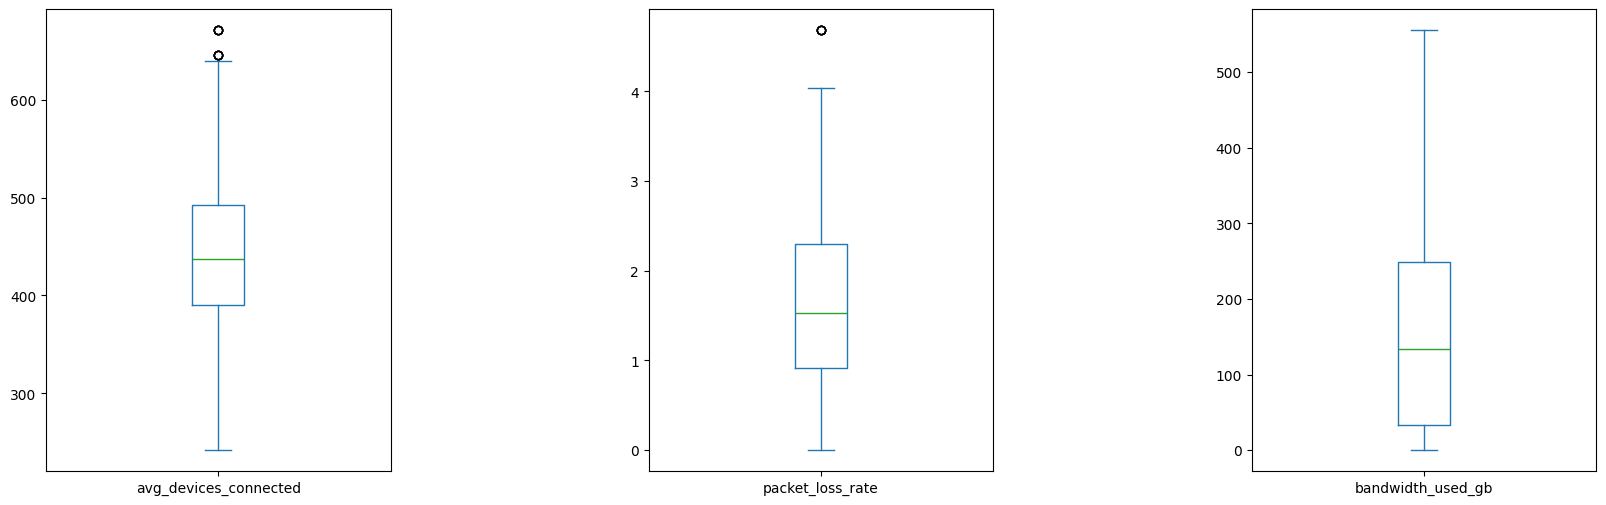

In [17]:
df.plot(kind="box",sharey=False,subplots=True,figsize=(20,6))
plt.subplots_adjust(wspace=0.75)
plt.show()

In [18]:
!pip install feature_engine
from feature_engine.outliers import Winsorizer
winsor=Winsorizer(capping_method="iqr",tail="both",fold=1.5,variables=["bandwidth_used_gb"])
df["bandwidth_used_gb"]=winsor.fit_transform(df[["bandwidth_used_gb"]])


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
winsor=Winsorizer(capping_method="iqr",tail="both",fold=1.5,variables=["avg_devices_connected"])
df["avg_devices_connected"]=winsor.fit_transform(df[["avg_devices_connected"]])

In [20]:
winsor=Winsorizer(capping_method="iqr",tail="both",fold=1.5,variables=["packet_loss_rate"])
df["packet_loss_rate"]=winsor.fit_transform(df[["packet_loss_rate"]])

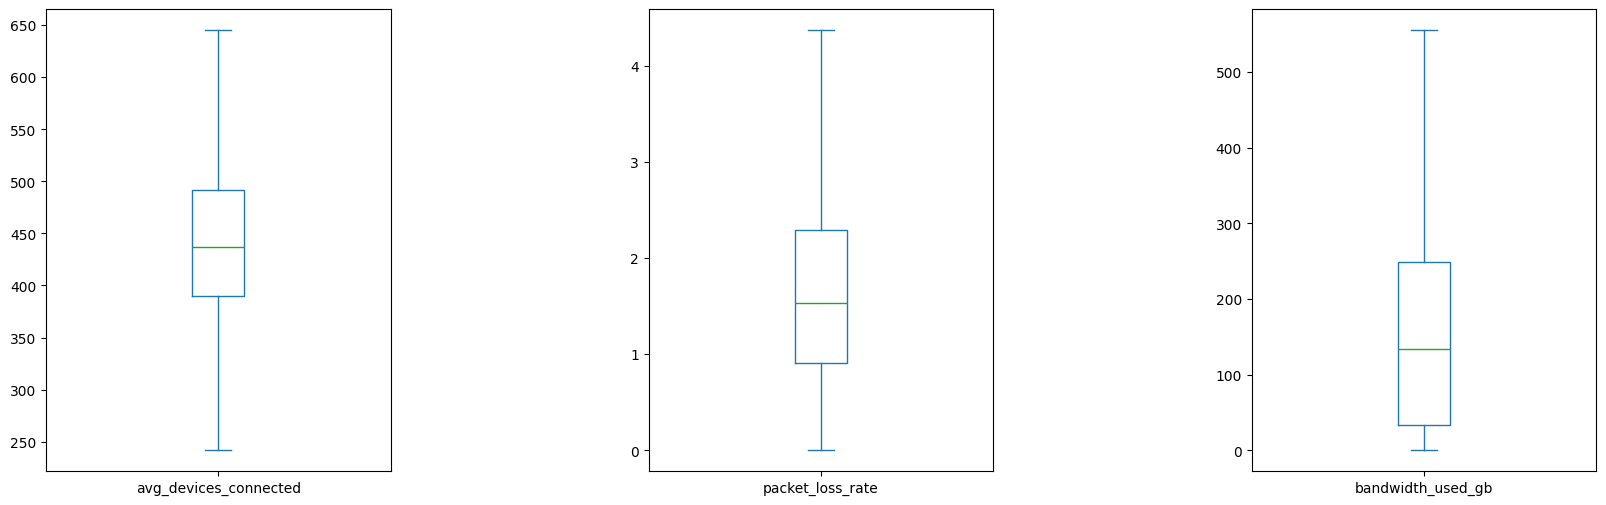

In [21]:
df.plot(kind="box",sharey=False,subplots=True,figsize=(20,6))
plt.subplots_adjust(wspace=0.75)
plt.show()

In [22]:
import seaborn as sns

In [23]:
df.columns

Index(['date', 'zone', 'is_weekend', 'is_exam', 'is_event',
       'avg_devices_connected', 'packet_loss_rate', 'bandwidth_used_gb'],
      dtype='object')

<Axes: xlabel='is_weekend', ylabel='bandwidth_used_gb'>

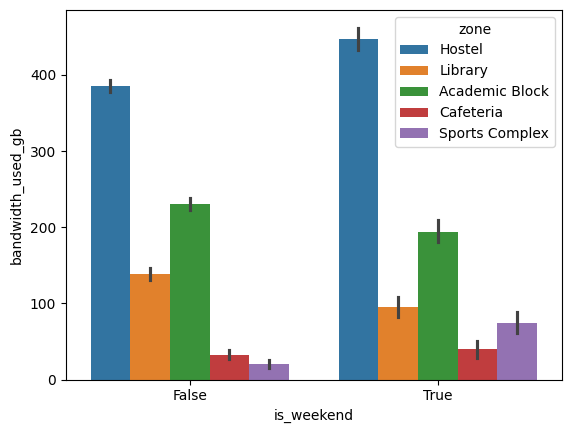

In [24]:
sns.barplot(
    data=df,
    x="is_weekend",
    y="bandwidth_used_gb",
    hue="zone"
)


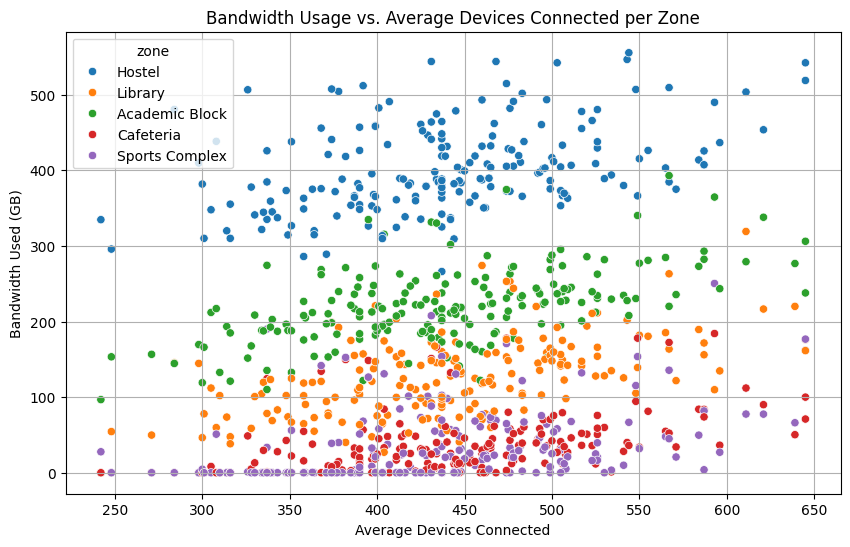

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='avg_devices_connected', y='bandwidth_used_gb', hue='zone')
plt.title('Bandwidth Usage vs. Average Devices Connected per Zone')
plt.xlabel('Average Devices Connected')
plt.ylabel('Bandwidth Used (GB)')
plt.grid(True)
plt.show()

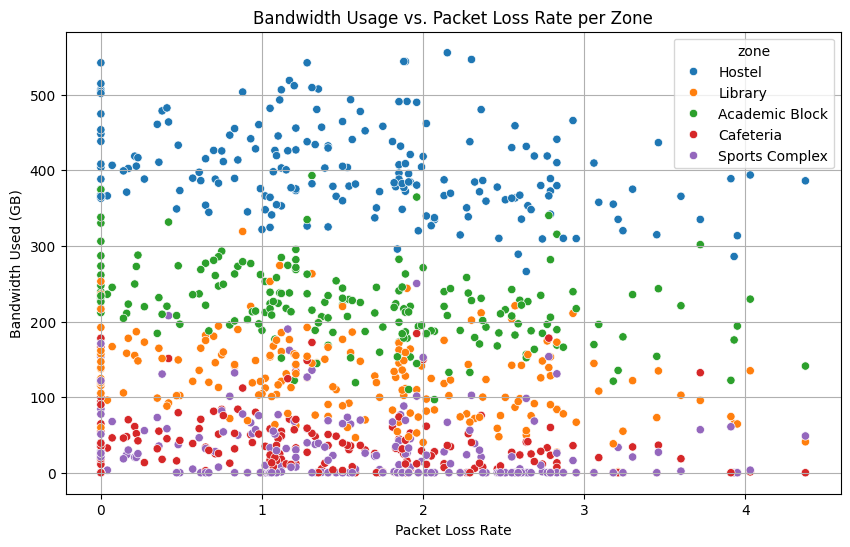

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='packet_loss_rate', y='bandwidth_used_gb', hue='zone')
plt.title('Bandwidth Usage vs. Packet Loss Rate per Zone')
plt.xlabel('Packet Loss Rate')
plt.ylabel('Bandwidth Used (GB)')

plt.grid(True)
plt.show()

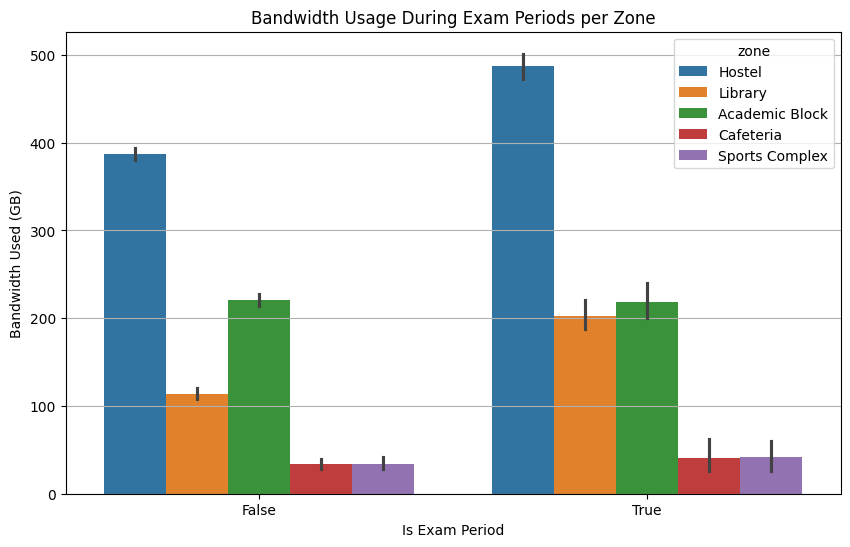

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='is_exam', y='bandwidth_used_gb', hue='zone')
plt.title('Bandwidth Usage During Exam Periods per Zone')
plt.xlabel('Is Exam Period')
plt.ylabel('Bandwidth Used (GB)')
plt.grid(axis='y')
plt.show()

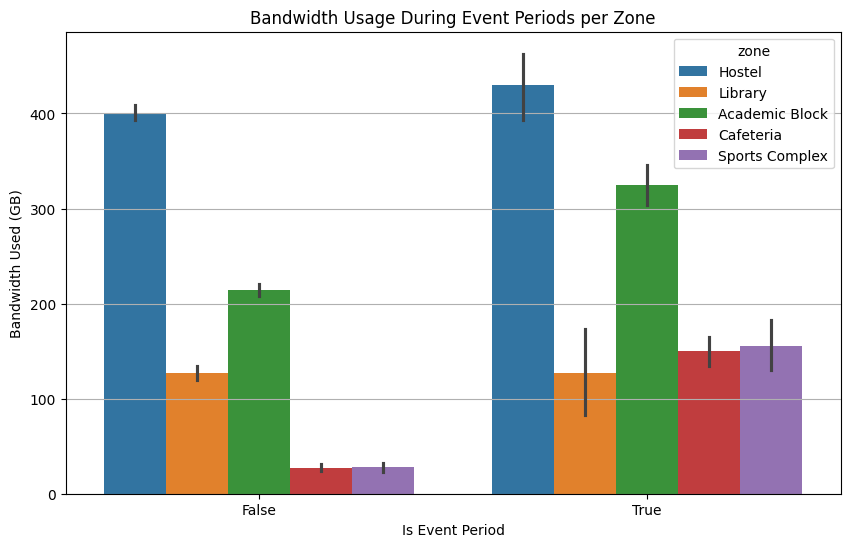

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='is_event', y='bandwidth_used_gb', hue='zone')
plt.title('Bandwidth Usage During Event Periods per Zone')
plt.xlabel('Is Event Period')
plt.ylabel('Bandwidth Used (GB)')
plt.grid(axis='y')
plt.show()

**FEATURE** **ENGINEERING**

In [29]:
df["zone"].unique()

array(['Hostel', 'Library', 'Academic Block', 'Cafeteria',
       'Sports Complex'], dtype=object)

In [30]:
# Make a clean copy
clean_df = df.copy()
clean_df = clean_df.drop_duplicates()
clean_df = clean_df[clean_df["bandwidth_used_gb"] >= 0].copy()
clean_df["date"] = pd.to_datetime(clean_df["date"])

print("\nAfter cleaning:")
print("Shape:", clean_df.shape)
print("Missing values:")
display(clean_df.isnull().sum())

print("Negative bandwidth rows:", (clean_df["bandwidth_used_gb"] < 0).sum())
print("Duplicate rows:", clean_df.duplicated().sum())



After cleaning:
Shape: (983, 8)
Missing values:


date                     0
zone                     0
is_weekend               0
is_exam                  0
is_event                 0
avg_devices_connected    0
packet_loss_rate         0
bandwidth_used_gb        0
dtype: int64

Negative bandwidth rows: 0
Duplicate rows: 0


FEATURE ENGINEERING

In [31]:
df["date"] = pd.to_datetime(df["date"])


In [32]:
df["day_of_week"] = df["date"].dt.dayofweek

In [33]:
df["month"] = df["date"].dt.month

In [34]:
df['rolling_avg_7'] = df.groupby('zone')['bandwidth_used_gb'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
df.head()

,date,zone,is_weekend,is_exam,is_event,avg_devices_connected,packet_loss_rate,bandwidth_used_gb,day_of_week,month,rolling_avg_7
0,2024-01-01,Hostel,False,False,False,565.0,1.12,403.1,0,1,403.1
1,2024-01-01,Library,False,False,False,565.0,1.12,185.3,0,1,185.3
2,2024-01-01,Academic Block,False,False,False,565.0,1.12,284.7,0,1,284.7
3,2024-01-01,Cafeteria,False,False,False,565.0,1.12,54.8,0,1,54.8
4,2024-01-01,Sports Complex,False,False,False,565.0,1.12,47.8,0,1,47.8


In [35]:
x=df.drop("bandwidth_used_gb",axis=1)
y=df["bandwidth_used_gb"]

In [36]:
## separating categorical and numerical columns
categorical = ["zone"]

numerical = [
    "is_weekend",
    "is_exam",
    "is_event",
    "avg_devices_connected",
    "packet_loss_rate",
    "day_of_week",
    "month",
    "previous_usage",
    "rolling_avg"
]

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical
        )
    ],
    remainder="passthrough"
)

In [38]:
handle_unknown="ignore"

In [39]:
from sklearn.model_selection import train_test_split

# Use the already defined X (x) and y variables for train-test split
X = x
y = y

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [41]:
lr_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['zone'])])),
                ('model', LinearRegression())])

In [42]:
# Necessary imports for defining the pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Define categorical features (from cell Hk8lSwt7QtIB)
categorical = ["zone"]

# Define the preprocessor (from cell Qhu1_513RStB)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical
        )
    ],
    remainder="passthrough"
)

# Define the Linear Regression pipeline (from cell yHD4IMcZRu-y)
lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Temporarily drop the 'date' column from X_train and X_test for fitting and prediction
# The 'date' column is a Timestamp type and not suitable for direct model input.
X_train_processed = X_train.drop('date', axis=1, errors='ignore')
X_test_processed = X_test.drop('date', axis=1, errors='ignore')

lr_model.fit(X_train_processed, y_train)
lr_pred = lr_model.predict(X_test_processed)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 983 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   983 non-null    datetime64[ns]
 1   zone                   983 non-null    object        
 2   is_weekend             983 non-null    bool          
 3   is_exam                983 non-null    bool          
 4   is_event               983 non-null    bool          
 5   avg_devices_connected  983 non-null    float64       
 6   packet_loss_rate       983 non-null    float64       
 7   bandwidth_used_gb      983 non-null    float64       
 8   day_of_week            983 non-null    int32         
 9   month                  983 non-null    int32         
 10  rolling_avg_7          983 non-null    float64       
dtypes: bool(3), datetime64[ns](1), float64(4), int32(2), object(1)
memory usage: 64.3+ KB


In [44]:
lr_model.fit(X_train_processed, y_train)

C:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['zone'])])),
                ('model', LinearRegression())])

In [45]:
lr_pred = lr_model.predict(X_test)

Evaluate Linear **Regression**

In [46]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

lr_r2 = r2_score(y_test, lr_pred)

lr_mse = mean_squared_error(y_test, lr_pred)

lr_rmse = np.sqrt(lr_mse)

lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression")
print("R2:", lr_r2)
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)

Linear Regression
R2: 0.9475915050542283
MSE: 1102.4283632000308
RMSE: 33.202836673995655
MAE: 26.117794001385697


Random Forest Regressor

In [47]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

In [48]:
rf_model.fit(X_train_processed, y_train)

C:\Users\parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['zone'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [49]:
rf_pred = rf_model.predict(X_test_processed)

Evaluate Random Forest

In [50]:
rf_r2 = r2_score(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = np.sqrt(rf_mse)

rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest")
print("R2:", rf_r2)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)

Random Forest
R2: 0.9680418999423294
MSE: 672.2481913288215
RMSE: 25.927749445889464
MAE: 19.23532656514382


Compare both models

In [51]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "R2": [
        lr_r2,
        rf_r2
    ],
    "MSE": [
        lr_mse,
        rf_mse
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ]
})

results

,Model,R2,MSE,RMSE,MAE
0,Linear Regression,0.947592,1102.428363,33.202837,26.117794
1,Random Forest,0.968042,672.248191,25.927749,19.235327


Select the Best Model

In [52]:
if rf_r2 > lr_r2:
    print("Random Forest is the better model")
else:
    print("Linear Regression is the better model")

Random Forest is the better model


In [53]:

# FINAL USER INPUT AND BANDWIDTH PREDICTION

print("------ Wi-Fi Bandwidth Prediction ------")

# Taking zone input
print("\nChoose Zone:")
print("1. Hostel")
print("2. Library")
print("3. Academic Block")
print("4. Cafeteria")
print("5. Sports Complex")

choice = int(input("Enter zone number (1-5): "))

# Conditional statements for zone
if choice == 1:
    zone = "Hostel"

elif choice == 2:
    zone = "Library"

elif choice == 3:
    zone = "Academic Block"

elif choice == 4:
    zone = "Cafeteria"

elif choice == 5:
    zone = "Sports Complex"

else:
    print("Invalid zone selected")
    zone = "Hostel" # Default to Hostel if invalid input


# Taking other inputs
weekend = bool(int(input("\nIs it weekend? (1 = Yes, 0 = No): ")))
exam = bool(int(input("Is there an exam? (1 = Yes, 0 = No): ")))
event = bool(int(input("Is there an event? (1 = Yes, 0 = No): ")))

devices = float(input("Enter average connected devices: "))
packet_loss = float(input("Enter packet loss rate: "))

day_of_week = int(input("Enter day of week (0 = Monday, 6 = Sunday): "))
month = int(input("Enter month (1-12): "))

# The model was trained with 'rolling_avg_7', not 'previous_usage'
rolling_avg_7_input = float(input("Enter rolling average bandwidth usage for the last 7 days: "))

------ Wi-Fi Bandwidth Prediction ------

Choose Zone:
1. Hostel
2. Library
3. Academic Block
4. Cafeteria
5. Sports Complex


Enter zone number (1-5):  1

Is it weekend? (1 = Yes, 0 = No):  0
Is there an exam? (1 = Yes, 0 = No):  0
Is there an event? (1 = Yes, 0 = No):  0
Enter average connected devices:  45
Enter packet loss rate:  2.5
Enter day of week (0 = Monday, 6 = Sunday):  5
Enter month (1-12):  5
Enter rolling average bandwidth usage for the last 7 days:  145


Now create the input DataFrame

In [56]:
# Create new data for prediction

new_data = pd.DataFrame({
    "zone": [zone],
    "is_weekend": [weekend],
    "is_exam": [exam],
    "is_event": [event],
    "avg_devices_connected": [devices],
    "packet_loss_rate": [packet_loss],
    "day_of_week": [day_of_week],
    "month": [month],
    "rolling_avg_7": [rolling_avg_7_input] # Corrected column name and input variable
})

# Final prediction

In [57]:
new_data

,zone,is_weekend,is_exam,is_event,avg_devices_connected,packet_loss_rate,day_of_week,month,rolling_avg_7
0,Hostel,False,False,False,45.0,2.5,5,5,145.0


In [59]:
# Predict bandwidth

best_model = rf_model


prediction = best_model.predict(new_data)

print("\n-----------------------------------")
print("Zone:", zone)
print("Predicted Bandwidth Usage:", round(prediction[0], 2), "GB")
print("-----------------------------------")


-----------------------------------
Zone: Hostel
Predicted Bandwidth Usage: 63.95 GB
-----------------------------------


In [60]:
import pickle

with open("jupyter_lab_wifi_bandwidth_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Model exported successfully!")

Model exported successfully!


In [61]:
print(rf_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['zone'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, random_state=42))])


In [62]:
rf_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['zone'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, random_state=42))])